In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())


Working in: /content/drive/MyDrive/DL_Group_MGI1


In [3]:
# Install dependencies if not already installed
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 24.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 69.8 MB/s eta 0:00:00


In [4]:
# Run this everytime you update something in the repo!
import os

REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

# if project directory is empty clone the repo, otherwise pull the latest changes
if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}

print("Working in:", os.getcwd())





Already up to date.
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


Download dataset

In [23]:

"Download the UCMerced Land Use dataset if not already present. "
"The dataset will be saved in the 'ucmdata' directory. "

import os
import zipfile
import subprocess
import shutil
if not os.path.exists('ucmdata'):
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')

    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
        zip_ref.extractall('UCMImages')

    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')
UCM_images_path = "/ucmdata/Images/"
Multilabels_path = "/ucmdata/LandUse_Multilabeled.txt"

print(os.listdir('.'))


['.git', 'GRS_34806_MGI_Project.ipynb', 'LICENSE', 'Level2_ResNet50_UCM', 'README.md', 'notebooks', 'ucmdata', '__pycache__', 'wandb', 'outputs']


Load Packages

In [6]:
 import random, shutil, zipfile
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
import torchvision.models as tvm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import torchmetrics
import re 

L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: Tesla T4


Class list and dataset

In [7]:
class UCMMultilabelDataset(Dataset):
    """
    UCM multilabel land-use dataset.
 
    Folder layout:
        ucmdata/
            Images/
                agricultural/   agricultural00.tif … agricultural99.tif
                airplane/       airplane00.tif      … airplane99.tif
                …               (21 subfolders, already in correct order)
            LandUse_Multilabeled.txt
 
    Label file format (tab-separated):
        IMAGE\LABEL   airplane   bare-soil   buildings   …   water
        agricultural00    0           0            0      …     0
        …
 
    Strategy
    --------
    1. Parse the label file → class names from the header (cols 1…end,
       skipping "IMAGE\LABEL") + label matrix (N × C).
    2. Walk ucmdata/Images/ subfolder-by-subfolder in sorted order, collecting
       every image path into a flat list — same traversal order as the txt file.
    3. Pair image_paths[i]  ↔  label_matrix[i]  by position (no name matching).
    """
 
    def __init__(
        self,
        root_dir: str = "ucmdata",
        label_file: str = "LandUse_Multilabeled.txt",
        transform=None,
        image_ext: str = ".tif",
    ):
        self.root_dir   = root_dir
        self.images_dir = os.path.join(root_dir, "Images")
        self.transform  = transform
        self.image_ext  = image_ext
 
        # ── 1. Parse label file ──────────────────────────────────────────
        label_path = os.path.join(root_dir, label_file)
        self.class_names, self.label_matrix = self._parse_labels(label_path)
        self.num_classes = len(self.class_names)
 
        # ── 2. Collect image paths in sorted subfolder order ─────────────
        self.image_paths = self._collect_image_paths()
 
        # ── 3. Sanity check ──────────────────────────────────────────────
        assert len(self.image_paths) == len(self.label_matrix), (
            f"Mismatch: {len(self.image_paths)} images found but "
            f"{len(self.label_matrix)} label rows in the txt file."
        )
 
    # ------------------------------------------------------------------ #
    def _parse_labels(self, label_path: str):
        """
        Returns:
            class_names  – list[str], length C  (column headers, cols 1…end)
            label_matrix – torch.FloatTensor, shape (N, C)
        """
        with open(label_path, "r") as f:
            lines = [l.strip() for l in f if l.strip()]
 
        # Header row → class names (skip the first column "IMAGE\LABEL")
        header      = lines[0].split("\t")
        class_names = header[1:]          # ['airplane', 'bare-soil', …, 'water']
 
        # Data rows → label matrix (parts[0] is the image name, ignored here)
        rows = []
        for line in lines[1:]:
            parts = line.split("\t")
            label_vals = list(map(int, parts[1:]))
            rows.append(label_vals)
 
        label_matrix = torch.tensor(rows, dtype=torch.float32)  # (N, C)
        return class_names, label_matrix
 
    # ------------------------------------------------------------------ #
    def _collect_image_paths(self) -> list:
        """
        Walks ucmdata/Images/ subfolder-by-subfolder in sorted order.
        Within each subfolder images are also sorted — matching the txt order.
        Returns a flat list of absolute image paths.
        """
        image_paths = []
 
        subfolders = sorted( entry.name for entry in os.scandir(self.images_dir)) 
        
 
        for subfolder in subfolders:
            folder_path = os.path.join(self.images_dir, subfolder)
            files = sorted(
                fname
                for fname in os.listdir(folder_path)
                if fname.lower().endswith(self.image_ext)
            )
            for fname in files:
                image_paths.append(os.path.join(folder_path, fname))
 
        return image_paths
 
    # ------------------------------------------------------------------ #
    def __len__(self) -> int:
        return len(self.image_paths)
 
    def __getitem__(self, idx: int):
        img_path = self.image_paths[idx]
        labels   = self.label_matrix[idx]          # float32 tensor, shape (C,)
 
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
 
        return image, labels
 
    # Utility helpers

    def get_class_names(self) -> list:
        return self.class_names
 
    def get_class_weights(self) -> torch.Tensor:
        """
        Inverse-frequency pos_weight per class for BCEWithLogitsLoss. Combines a Sigmoid layer and the Binary Cross Entropy (BCE) loss into one single class
        Shape: (num_classes,)
        """
        pos = self.label_matrix.sum(dim=0).clamp(min=1)
        neg = (len(self) - self.label_matrix.sum(dim=0)).clamp(min=1)
        return neg / pos
 
    def verify_alignment(self, n_samples: int = 10):
        """
        Prints the first n_samples rows so you can visually cross-check
        image names against the txt file.
        """
        print(f"{'Image path':<55}  {'Active labels'}")
        print("-" * 80)
        for i in range(min(n_samples, len(self))):
            active = [self.class_names[j]
                      for j, v in enumerate(self.label_matrix[i]) if v == 1]
            short = os.path.join(*self.image_paths[i].split(os.sep)[-2:])
            print(f"{short:<55}  {active}")
 

<>:14: SyntaxWarning: invalid escape sequence '\L'
<>:14: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_6565/2929272064.py:14: SyntaxWarning: invalid escape sequence '\L'
  IMAGE\LABEL   airplane   bare-soil   buildings   …   water


Augmentation  

In [8]:
IMAGE_SIZE = (224, 224)
def get_transforms(split: str = "train"):
    """Standard augmentation."""
    if split == "train":
        return transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(45),
            transforms.ColorJitter(brightness=0.2, contrast=0.4, saturation=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], # to prevent exploding gradients 
                                 std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(IMAGE_SIZE),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225]),
        ])
 
 

Data split 

In [9]:
def build_dataloaders(
    root_dir:    str   = "ucmdata",
    label_file:  str   = "LandUse_Multilabeled.txt",
    batch_size:  int   = 32,
    num_workers: int   = 4,
    val_frac:    float = 0.15,
    test_frac:   float = 0.15,
    seed:        int   = 42,
    image_ext:   str   = ".tif",
):
    """
    Returns (train_loader, val_loader, test_loader, class_names, pos_weights).
 
    Usage
    -----
    train_loader, val_loader, test_loader, classes, pos_w = build_dataloaders()
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_w)
    """
    
 
    full_ds = UCMMultilabelDataset(
        root_dir=root_dir, label_file=label_file,
        transform=None, image_ext=image_ext,
    )
 
    n = len(full_ds)
    labels_array = full_ds.label_matrix.numpy()  # Convert to numpy
    
    # First split: train+val vs test
    splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=test_frac, random_state=seed
    )
    train_val_idx, test_idx = next(splitter.split(np.zeros(n), labels_array))
    
    # Second split: train vs val from train+val
    train_val_labels = labels_array[train_val_idx]
    val_frac_adjusted = val_frac / (1 - test_frac)  # Adjust fraction for remaining data
    
    splitter2 = MultilabelStratifiedShuffleSplit(
        n_splits=1, test_size=val_frac_adjusted, random_state=seed
    )
    train_idx_local, val_idx_local = next(splitter2.split(
        np.zeros(len(train_val_idx)), train_val_labels
    ))
    
    # Map back to original indices
    train_idx = train_val_idx[train_idx_local]
    val_idx = train_val_idx[val_idx_local]
    
    def make_subset(split_name, indices):
        ds = UCMMultilabelDataset(
            root_dir=root_dir, label_file=label_file,
            transform=get_transforms(split_name), image_ext=image_ext,
        )
        return Subset(ds, indices)
    
    train_ds = make_subset("train", train_idx)
    val_ds   = make_subset("val",   val_idx)
    test_ds  = make_subset("test",  test_idx)
    
    kw = dict(batch_size=batch_size, num_workers=num_workers,
              pin_memory=torch.cuda.is_available())
 
    return (
        DataLoader(train_ds, shuffle=True,  **kw),
        DataLoader(val_ds,   shuffle=True, **kw),
        DataLoader(test_ds,  shuffle=False, **kw),
        full_ds.get_class_names(),
        full_ds.get_class_weights(),
    )
 
 

In [10]:
# Full dataloader test
train_loader, val_loader, test_loader, classes, pos_w = build_dataloaders()

# Check class distributions
train_labels = torch.cat([labels for _, labels in train_loader]).numpy()
val_labels = torch.cat([labels for _, labels in val_loader]).numpy()
test_labels = torch.cat([labels for _, labels in test_loader]).numpy()

print("Train class freq:", train_labels.sum(axis=0))
print("Val   class freq:", val_labels.sum(axis=0))
print("Test  class freq:", test_labels.sum(axis=0))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train class freq: [ 70. 502. 483. 620.  81.  73.  70.  72. 682.  72. 903. 206.  70.  72.
  70. 706. 142.]
Val   class freq: [ 15. 108. 104. 133.  17.  16.  15.  16. 147.  15. 196.  44.  15.  15.
  15. 152.  31.]
Test  class freq: [ 15. 108. 104. 133.  17.  16.  15.  15. 146.  15. 201.  44.  15.  15.
  15. 151.  30.]


Initialize WANDB

In [11]:

import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abelchachoek (abelchachoek-wur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Hyperparameters 

In [ ]:
# Define hyperparameters
PRETRAINED_MODEL = "resnet50"
NUM_CLASSES = len(classes)
MAX_EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-5
run_count = 1


Log WandB

In [ ]:
run = wandb.init(project="multilabel-classification", # or single-label                 
                 name="ML_ptResNet50_" + str(run_count), # replace with specific name
                 config={
                     "pretrained_model": PRETRAINED_MODEL,
                     "classes": NUM_CLASSES,
                     "max_epochs": MAX_EPOCHS,
                     "learning_rate": LR,
                     "weight_decay": WEIGHT_DECAY,
                     }) 


Load and train model

In [14]:
def build_resnet50(num_classes):
    weights = tvm.ResNet50_Weights.IMAGENET1K_V2
    model = tvm.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

backbone = build_resnet50(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f"ResNet-50 trainable parameters: {n_params:,}  |  output logits: {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s] 


ResNet-50 trainable parameters: 23,542,865  |  output logits: 17


RESNET Head

In [15]:
class LitResNetMultilabel(L.LightningModule):
    def __init__(self, model, num_classes, lr=1e-4, weight_decay=1e-4,
                 max_epochs=15, threshold=0.5, pos_weight=None):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        pos_weight = torch.as_tensor(pos_weight, dtype=torch.float32) if pos_weight is not None else None

        self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        self.threshold = threshold

        mk = dict(task="multilabel", num_labels=num_classes, threshold=threshold)
        self.train_f1 = torchmetrics.F1Score(average="macro", **mk)
        self.val_f1   = torchmetrics.F1Score(average="macro", **mk)
        self.test_f1  = torchmetrics.F1Score(average="macro", **mk)
        self.val_acc  = torchmetrics.Accuracy(average="macro", **mk)
        self.test_acc = torchmetrics.Accuracy(average="macro", **mk)
        self.val_map  = torchmetrics.AveragePrecision(task="multilabel", num_labels=num_classes, average="macro")
        self.test_map = torchmetrics.AveragePrecision(task="multilabel", num_labels=num_classes, average="macro")

    def forward(self, x):
        return self.model(x)

    def _step(self, batch):
        imgs, labels = batch          # labels: float tensor (B, C)
        logits = self(imgs)
        loss = self.criterion(logits, labels)
        return loss, logits, labels

    def training_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.train_f1.update(logits, labels.int())
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_f1",   self.train_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.val_f1.update(logits, labels.int())
        self.val_acc.update(logits, labels.int())
        self.val_map.update(logits, labels.int())
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_f1",   self.val_f1,  on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc",  self.val_acc, on_step=False, on_epoch=True)
        self.log("val_map",  self.val_map, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        loss, logits, labels = self._step(batch)
        self.test_f1.update(logits, labels.int())
        self.test_acc.update(logits, labels.int())
        self.test_map.update(logits, labels.int())
        self.log("test_loss", loss, on_step=False, on_epoch=True)
        self.log("test_f1",   self.test_f1,  on_step=False, on_epoch=True)
        self.log("test_acc",  self.test_acc, on_step=False, on_epoch=True)
        self.log("test_map",  self.test_map, on_step=False, on_epoch=True)

    def predict_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= self.threshold).int()
        return {"probs": probs, "preds": preds, "labels": labels.int()}

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(),
                                      lr=self.hparams.lr,
                                      weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.hparams.max_epochs)
        return [optimizer], [scheduler]

Training

In [16]:
lit_model = LitResNetMultilabel(model=backbone, num_classes=NUM_CLASSES,
                                lr=LR, weight_decay=WEIGHT_DECAY, max_epochs=MAX_EPOCHS, pos_weight=pos_w)

checkpoint_cb = ModelCheckpoint(
    dirpath="outputs/checkpoints",
    filename="resnet50-multilabel-best-{epoch:02d}-{val_f1:.4f}",
    monitor="val_f1", mode="max", save_top_k=1, save_weights_only=True,
)
csv_logger = CSVLogger(save_dir="outputs/logs", name="resnet50_multilabel")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_cb],
    logger=csv_logger,
    log_every_n_steps=10,
)
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet                     │ 23.5 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 23.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 23.5 M                                                                                               
Total estimated model params size (MB): 94                                                                         
Modules in train mode: 159                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your 
`val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for 
val/test dataloaders.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples found
in target, recall is undefined. Setting recall to one for all thresholds.
  warnings.warn(*args, **kwargs)

INFO: `Trainer.fit` stopped: `max_epochs=15` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


Final classification on test data

In [ ]:
# Evaluate using the best checkpoint
trainer.test(lit_model, dataloaders=test_loader, ckpt_path="best")

best_path = checkpoint_cb.best_model_path
print(f"Best checkpoint: {best_path}")
lit_model = LitResNetMultilabel.load_from_checkpoint(best_path, model=lit_model.model)

# Collect probs, preds and ground-truth for downstream analysis
preds_out = trainer.predict(lit_model, dataloaders=test_loader)
test_probs  = torch.cat([b["probs"]  for b in preds_out], dim=0).cpu().numpy()
test_preds  = torch.cat([b["preds"]  for b in preds_out], dim=0).cpu().numpy()
test_labels = torch.cat([b["labels"] for b in preds_out], dim=0).cpu().numpy()

from sklearn.metrics import f1_score, average_precision_score, hamming_loss

macro_f1  = f1_score(test_labels, test_preds, average="macro",  zero_division=0)
micro_f1  = f1_score(test_labels, test_preds, average="micro",  zero_division=0)
samples_f1 = f1_score(test_labels, test_preds, average="samples", zero_division=0)
macro_map = average_precision_score(test_labels, test_probs, average="macro")
hamming   = hamming_loss(test_labels, test_preds)
subset_acc = (test_preds == test_labels).all(axis=1).mean()  # exact-match

print(f"\nTest macro F1   : {macro_f1:.4f}")
print(f"Test micro F1   : {micro_f1:.4f}")
print(f"Test samples F1 : {samples_f1:.4f}")
print(f"Test macro mAP  : {macro_map:.4f}")
print(f"Hamming loss    : {hamming:.4f}")
print(f"Exact-match acc : {subset_acc:.4f}")



INFO: Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=12-val_f1=0.9352.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=12-val_f1=0.9352.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=12-val_f1=0.9352.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=12-val_f1=0.9352.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9554139971733093     │
│          test_f1          │    0.9306042194366455     │
│         test_loss         │    0.12957438826560974    │
│         test_map          │    0.9775964021682739     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/resnet50-multilabel-best-epoch=12-val_f1=0.9352.ckpt


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Output()


Test macro F1   : 0.9306
Test micro F1   : 0.8908
Test samples F1 : 0.8990
Test macro mAP  : 0.9776
Hamming loss    : 0.0446
Exact-match acc : 0.4809


Log Results

In [19]:
run.log({"macro_f1": macro_f1, "micro_f1": micro_f1, "samples_f1": samples_f1,
         "macro_map": macro_map, "hamming_loss": hamming, "subset_acc": subset_acc})


run.finish()

hamming_loss,▁
macro_f1,▁
macro_map,▁
micro_f1,▁
samples_f1,▁
subset_acc,▁
hamming_loss,0.04459
macro_f1,0.9306
macro_map,0.9776
micro_f1,0.89083
samples_f1,0.89902


Visualize

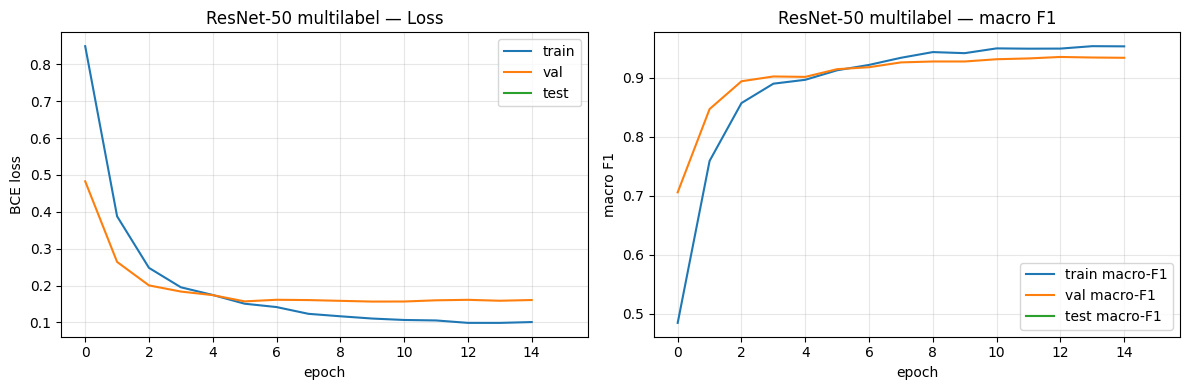

In [ ]:
metrics_csv = Path(csv_logger.log_dir) / "metrics.csv"
df = pd.read_csv(metrics_csv)
epoch_df = df.groupby("epoch").mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if "train_loss" in epoch_df:
    axes[0].plot(epoch_df["epoch"], epoch_df["train_loss"], label="train")
if "val_loss" in epoch_df:
    axes[0].plot(epoch_df["epoch"], epoch_df["val_loss"], label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("ResNet-50 multilabel — Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

if "train_f1" in epoch_df:
    axes[1].plot(epoch_df["epoch"], epoch_df["train_f1"], label="train macro-F1")
if "val_f1" in epoch_df:
    axes[1].plot(epoch_df["epoch"], epoch_df["val_f1"], label="val macro-F1")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro F1")
axes[1].set_title("ResNet-50 multilabel — macro F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
Path("outputs").mkdir(exist_ok=True)
plt.savefig("outputs/resnet50_multilabel_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

Examples of images

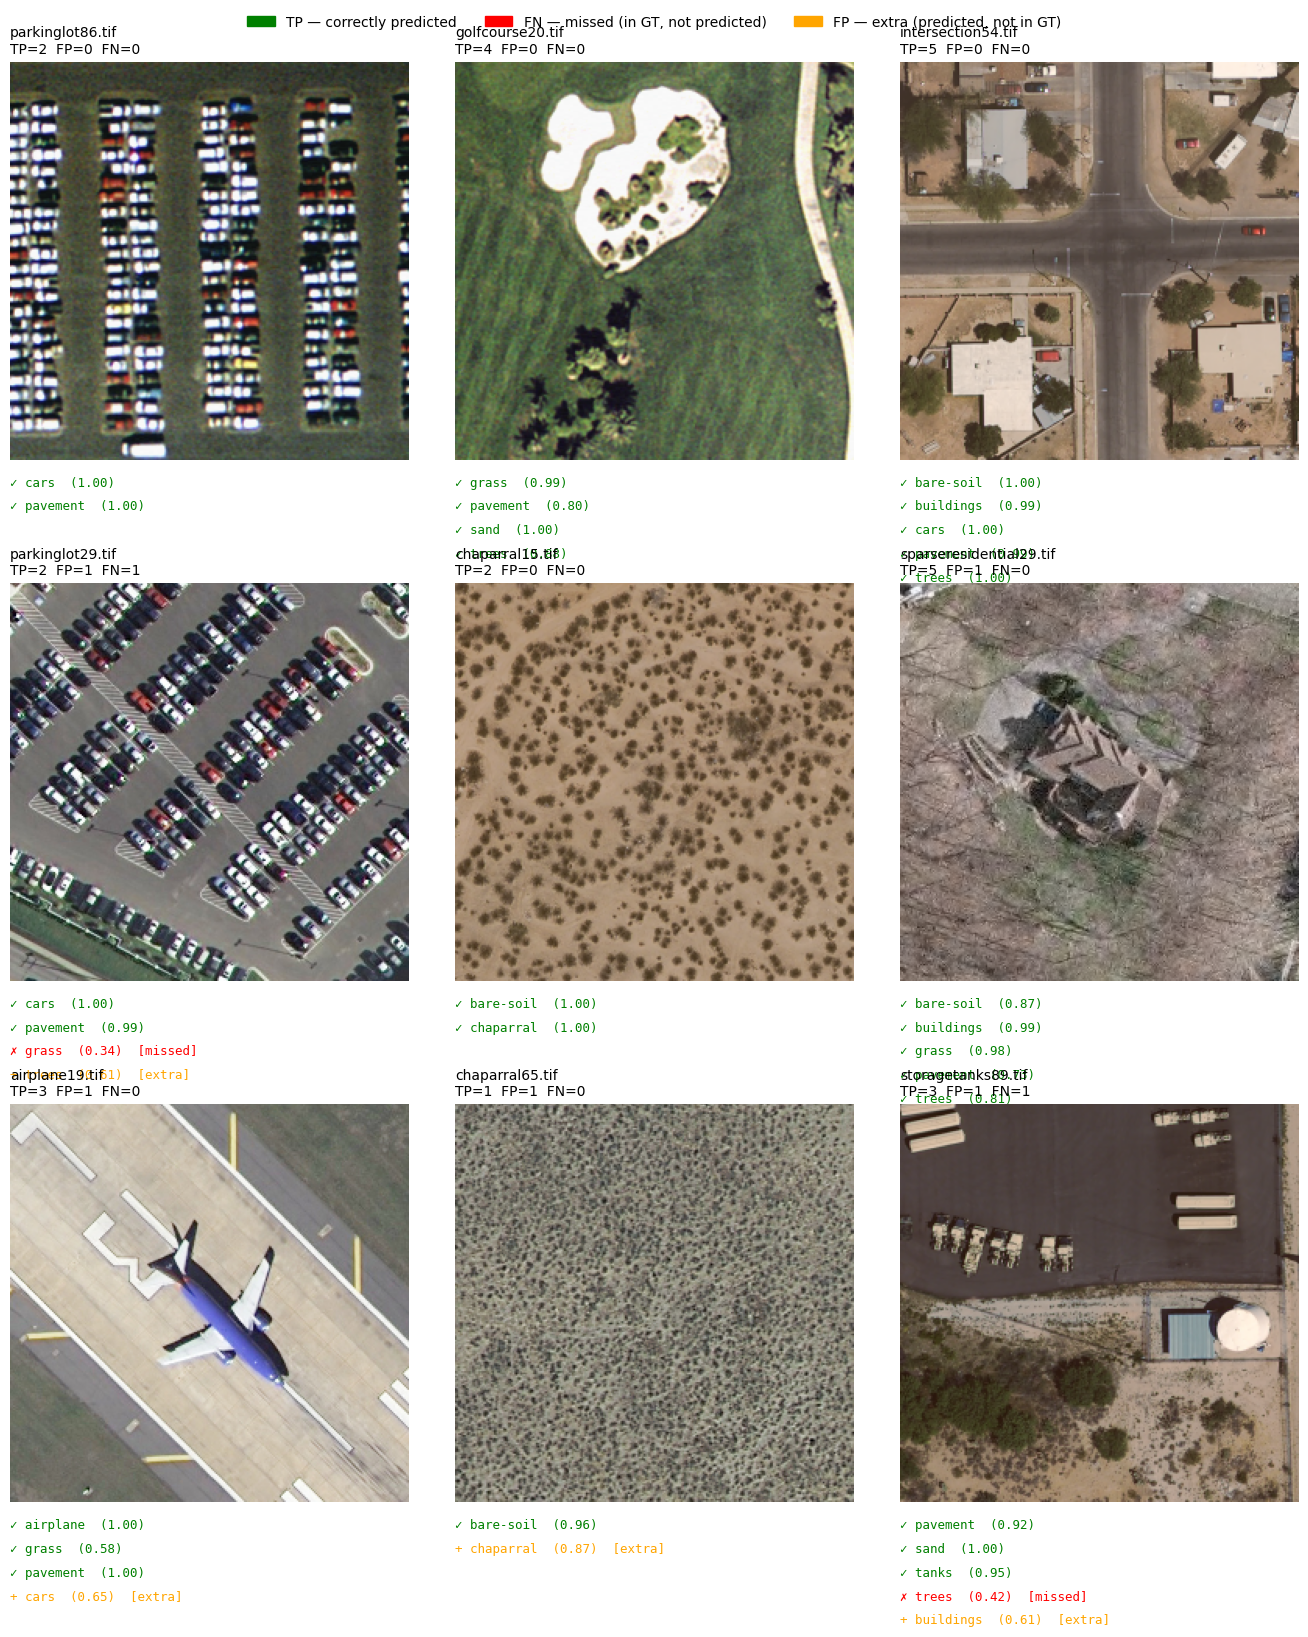

In [ ]:
test_ds_full = UCMMultilabelDataset(root_dir="ucmdata", label_file="LandUse_Multilabeled.txt", transform=None)
test_ds_subset = test_loader.dataset  # This is the Subset object
test_indices = test_ds_subset.indices  # Get the indices

# Map indices to image paths
test_items = [(test_ds_full.image_paths[idx], None) for idx in test_indices]


# Grid of test images with ground-truth vs predicted labels
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

N_SHOW = 9                       # 3x3 grid
COLS = 3
ROWS = (N_SHOW + COLS - 1) // COLS

# Pick a mix: a few "easy" (all correct), a few with at least one mistake.
errors_per_sample = (test_preds != test_labels).sum(axis=1)
correct_idx  = np.where(errors_per_sample == 0)[0]
wrong_idx    = np.where(errors_per_sample > 0)[0]

rng_show = np.random.default_rng(0)
n_correct = min(N_SHOW // 2, len(correct_idx))
n_wrong   = N_SHOW - n_correct
chosen = np.concatenate([
    rng_show.choice(correct_idx, n_correct, replace=False),
    rng_show.choice(wrong_idx,   n_wrong,   replace=False),
])
rng_show.shuffle(chosen)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 4.5, ROWS * 5.2))
axes = axes.flatten()

for ax, sample_i in zip(axes, chosen):
    rel_path, _ = test_items[sample_i]
    img = Image.open( rel_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

    gt   = test_labels[sample_i].astype(bool)
    pred = test_preds[sample_i].astype(bool)
    probs = test_probs[sample_i]

    tp = gt &  pred
    fp = ~gt &  pred       # predicted but not in GT
    fn = gt  & ~pred       # in GT but missed

    # Header: filename + TP/FP/FN counts
    fname = Path(rel_path).name
    ax.set_title(f"{fname}\nTP={tp.sum()}  FP={fp.sum()}  FN={fn.sum()}",
                 fontsize=10, loc="left")

    # Build a colored caption beneath the image
    lines = []
    for i in np.where(tp)[0]:
        lines.append(("green",  f"✓ {classes[i]}  ({probs[i]:.2f})"))
    for i in np.where(fn)[0]:
        lines.append(("red",    f"✗ {classes[i]}  ({probs[i]:.2f})  [missed]"))
    for i in np.where(fp)[0]:
        lines.append(("orange", f"+ {classes[i]}  ({probs[i]:.2f})  [extra]"))

    # Render the colored lines stacked under the image
    for j, (color, text) in enumerate(lines):
        ax.text(0.0, -0.04 - 0.06 * j, text, transform=ax.transAxes,
                fontsize=9, color=color, va="top", ha="left", family="monospace")

# Hide any unused axes
for ax in axes[len(chosen):]:
    ax.axis("off")

# Legend
legend_handles = [
    mpatches.Patch(color="green",  label="TP — correctly predicted"),
    mpatches.Patch(color="red",    label="FN — missed (in GT, not predicted)"),
    mpatches.Patch(color="orange", label="FP — extra (predicted, not in GT)"),
]
fig.legend(handles=legend_handles, loc="upper center",
           bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

plt.tight_layout()
#Path("outputs").mkdir(exist_ok=True)
#plt.savefig("outputs/resnet50_multilabel_predictions_grid.png",
            #dpi=150, bbox_inches="tight")
plt.show()